[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch11.ipynb)

Notebook Bab 11 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal dan data yang Anda kerjakan sendiri.

Karena memakai *pretrained model* (SBERT), notebook ini paling praktis dijalankan di **Google Colab** (klik badge di atas). Sel `%pip install` memasang pustaka yang diperlukan, dan GPU Colab mempercepat *encoding*.

## Persiapan

Sel ini memasang pustaka lalu mengimpor semua yang dibutuhkan.

In [1]:
%pip install -q sentence-transformers scikit-learn matplotlib

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
from sentence_transformers import SentenceTransformer

RANDOM_STATE = 42
print('Setup selesai.')

Setup selesai.


## Section 1 - Demo: Klasifikasi Dokumen, TF-IDF vs. *Embedding* Kontekstual

Kita membandingkan dua representasi pada tugas klasifikasi dokumen yang sama: representasi yang *dirancang manusia* (pembobotan leksikal TF-IDF) melawan representasi yang *dipelajari mesin* (SBERT). Kedua representasi diumpankan ke pengklasifikasi yang sama persis (regresi logistik) supaya yang dibandingkan murni kualitas fiturnya.

## Memuat data (20 Newsgroups)

Empat kategori dengan topik yang cukup berbeda. Bagian *header*, *footer*, dan kutipan dibuang agar model tidak menghafal metadata.

In [2]:
kategori = ['rec.sport.hockey', 'sci.med', 'comp.graphics', 'talk.politics.mideast']
data = fetch_20newsgroups(subset='all', categories=kategori,
                          remove=('headers', 'footers', 'quotes'),
                          random_state=RANDOM_STATE)
docs_train, docs_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.25,
    random_state=RANDOM_STATE, stratify=data.target)
print('Dokumen latih:', len(docs_train), '| uji:', len(docs_test))
print('Kelas:', data.target_names)

Dokumen latih: 2926 | uji: 976
Kelas: ['comp.graphics', 'rec.sport.hockey', 'sci.med', 'talk.politics.mideast']


## Representasi 1 - TF-IDF (*dirancang manusia*)

Kunci *praktik pipeline yang benar*: *vectorizer* TF-IDF diletakkan di dalam *pipeline*, sehingga kosakata hanya di-*fit* dari data *training*. Bila *vectorizer* di-*fit* pada seluruh korpus sebelum *split*, kata yang hanya ada di data uji ikut membentuk kolom fitur (*vocabulary leakage*).

In [3]:
pipe_tfidf = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, stop_words='english', min_df=2, ngram_range=(1, 2))),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
pipe_tfidf.fit(docs_train, y_train)
pred_tfidf = pipe_tfidf.predict(docs_test)
acc_tfidf = accuracy_score(y_test, pred_tfidf)
f1_tfidf = f1_score(y_test, pred_tfidf, average='macro')
print(f'TF-IDF  | akurasi = {acc_tfidf:.4f} | F1-macro = {f1_tfidf:.4f}')

TF-IDF  | akurasi = 0.9324 | F1-macro = 0.9326


## Representasi 2 - SBERT (*dipelajari mesin*)

SBERT dipakai sebagai *feature extractor* beku (*frozen*): bobotnya tidak dilatih ulang, hanya dipakai mengubah teks menjadi vektor padat. Tiap *split* di-*encode* terpisah, lalu vektornya masuk ke regresi logistik yang sama seperti pembanding TF-IDF.

In [4]:
encoder = SentenceTransformer('all-MiniLM-L6-v2')
emb_train = encoder.encode(docs_train, batch_size=64, show_progress_bar=False, normalize_embeddings=True)
emb_test = encoder.encode(docs_test, batch_size=64, show_progress_bar=False, normalize_embeddings=True)

clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
clf.fit(emb_train, y_train)
pred_emb = clf.predict(emb_test)
acc_emb = accuracy_score(y_test, pred_emb)
f1_emb = f1_score(y_test, pred_emb, average='macro')
print(f'SBERT   | akurasi = {acc_emb:.4f} | F1-macro = {f1_emb:.4f}')
print('Dimensi embedding:', emb_train.shape[1])

SBERT   | akurasi = 0.9273 | F1-macro = 0.9274
Dimensi embedding: 384


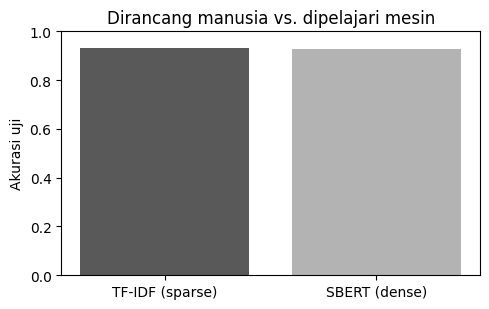

In [5]:
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(['TF-IDF (sparse)', 'SBERT (dense)'], [acc_tfidf, acc_emb], color=['0.35', '0.7'])
ax.set_ylim(0, 1)
ax.set_ylabel('Akurasi uji')
ax.set_title('Dirancang manusia vs. dipelajari mesin')
plt.tight_layout()
plt.show()

> 🔎 **Amati.** Karena pengklasifikasinya sama, selisih akurasi murni mencerminkan kualitas representasi. TF-IDF cenderung kuat ketika tiap kelas punya kata kunci yang sangat khas, sedangkan *embedding* SBERT unggul saat makna lebih menentukan daripada kecocokan kata persis dan saat ada banyak variasi kata. Selain itu, *vectorizer* TF-IDF berada di dalam *pipeline*, jadi kosakatanya tidak pernah belajar dari data uji.

## Section 2 - Mini Project

## Soal

Anda diberi data ulasan produk berbahasa Indonesia (`data/ch11_reviews.csv`, kolom `teks` dan `label` dengan 1 = positif, 0 = negatif).

Tugas:

1. Bangun *pipeline* klasifikasi sentimen berbasis **TF-IDF** + regresi logistik. Pastikan *vectorizer* berada di dalam *pipeline* agar kosakata hanya di-*fit* dari data *training* (hindari *vocabulary leakage*).
2. Bangun pembanding berbasis **embedding** (boleh SBERT multibahasa, misalnya `paraphrase-multilingual-MiniLM-L12-v2`) + regresi logistik.
3. Bandingkan akurasi keduanya dan jelaskan kapan tiap representasi lebih unggul.

**Catatan *leakage*:** periksa apakah ada teks duplikat yang bisa bocor melintasi *split*; jika ada, lakukan deduplikasi atau *group split* berdasarkan sumber.

**Luaran:** kode kedua *pipeline*, tabel akurasi, dan 3-4 kalimat analisis.

**Kriteria penilaian:** (a) tidak ada *fit* *vectorizer* pada data uji; (b) perbandingan adil (pengklasifikasi sama); (c) analisis menyebut trade-off *sparse* vs *dense*. Catatan: dataset ini kecil, jadi sebutkan keterbatasannya pada analisis Anda.

In [6]:
import os
import pandas as pd

# Memuat data awal. Pakai berkas lokal bila ada; jika tidak (mis. di Colab), unduh dari GitHub.
path = 'data/ch11_reviews.csv'
if not os.path.exists(path):
    path = 'https://raw.githubusercontent.com/muhammad-zainal-muttaqin/NulisBuku/main/website/notebooks/data/ch11_reviews.csv'
reviews = pd.read_csv(path)
print('Jumlah ulasan:', len(reviews))
print('Distribusi label:', reviews['label'].value_counts().to_dict())
reviews.head()

Jumlah ulasan: 30
Distribusi label: {1: 15, 0: 15}


,teks,label
0,Barangnya sesuai foto dan pengirimannya cepat ...,1
1,"Kualitas bahan terasa premium, jahitannya rapi",1
2,"Sudah dipakai seminggu, baterainya awet sehari...",1
3,Pelayanan penjualnya ramah dan responsif saat ...,1
4,Harga segini dapat kualitas seperti ini jelas ...,1


In [ ]:
# Kerjakan di sini.
# Bangun dua pipeline (TF-IDF dan embedding), latih, lalu bandingkan akurasinya.
